In [1]:
%reload_ext autoreload
%autoreload 2

from analytic_pes import AnalyticPES
from ssw.path import Image
from ssw.dimer import BasicDimer
from matplotlib import pyplot as plt
import numpy as np

plt.style.use('acs')

In [2]:
pes = AnalyticPES(
        function_name = "muller_brown_three_stats",
        use_jax= True
    )

In [3]:
start_p = [-0.1, 0.5]
img = Image(image=start_p)
energy = pes.get_potential_energy(x=img.data[:, 0], y=img.data[:, 1])

In [4]:
bd = BasicDimer(
    start_p,
    calculator=pes,
    norm=np.array([0.5, 0.5]),
    delta_r=0.05,
)
images_list = bd.run_modified_newton(max_steps=100, trial_angles=1, tol=1e-2)

Starting dimer run...
Initial norm: [[0.70710678 0.70710678]]
Step  Curvature       Rotation (deg) 
0     258.8459 1.0000
1     118.6670 -1236.5724
2     166.0231 -884.9425
Converged at step 2


In [5]:
bd = BasicDimer(
    start_p,
    calculator=pes,
    norm=np.array([0.5, 0.5]),
    delta_r=0.05,
)
images_list_1 = bd.run_modified_newton_analytical(max_steps=100, trial_angles=1, tol=1e-2)

Starting dimer run...
Initial norm: [[0.70710678 0.70710678]]
Step  Curvature       Rotation (deg) 
0     258.8459 1.0000
1     465.4236 -44.9920
2     258.8449 -44.9919
3     465.4243 -44.9920
4     258.8394 -44.9919
5     465.4232 -44.9920
6     258.8455 -44.9919
7     465.4240 -44.9920
8     258.8449 -44.9919
9     465.4240 -44.9920
10    258.8452 -44.9919
11    465.4242 -44.9920
12    258.8444 -44.9919
13    465.4242 -44.9920
14    258.8394 -44.9919
15    465.4232 -44.9920
16    258.8402 -44.9919
17    465.4232 -44.9920
18    258.8402 -44.9919
19    465.4232 -44.9920
20    258.8402 -44.9919
21    465.4240 -44.9920
22    258.8341 -44.9919
23    465.4236 -44.9920
24    258.8350 -44.9919
25    465.4232 -44.9920
26    258.8341 -44.9919
27    465.4242 -44.9920
28    258.8350 -44.9919
29    465.4232 -44.9920
30    258.8350 -44.9919
31    465.4240 -44.9920
32    258.8287 -44.9919
33    465.4236 -44.9920
34    258.8289 -44.9919
35    465.4236 -44.9920
36    258.8242 -44.9919
37    465.4228

Text(0.5, 1.0, 'Dimer Method on Muller-Brown PES')

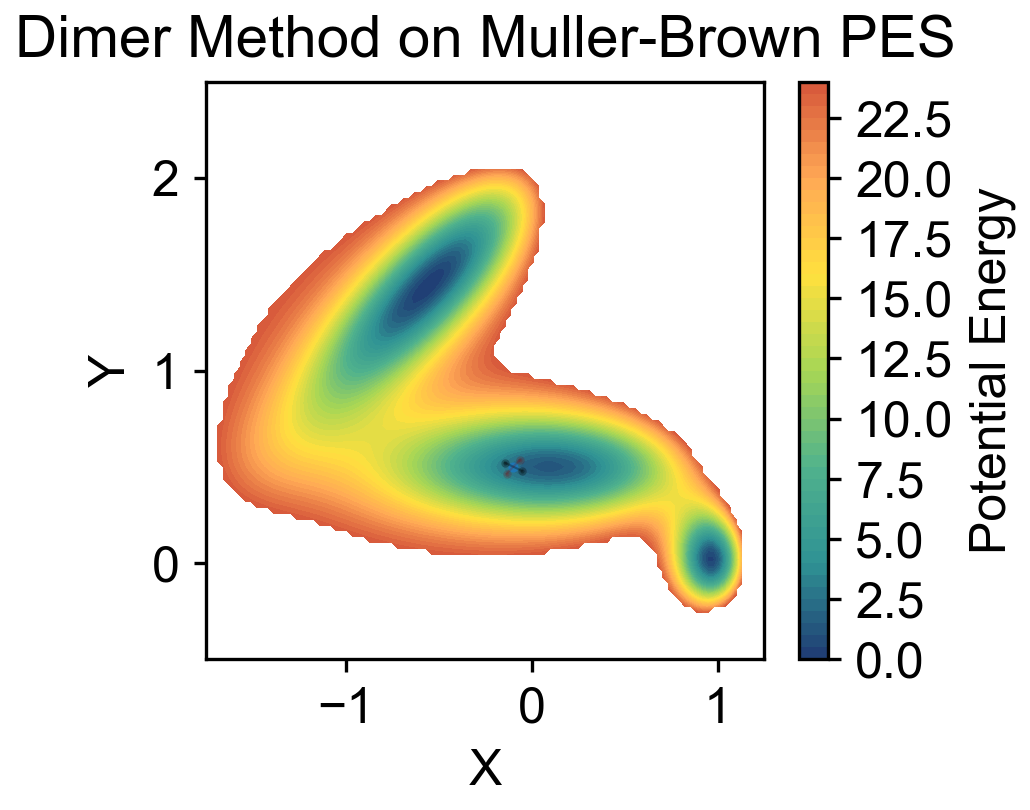

In [7]:
fig, ax = plt.subplots(figsize=(3, 2.5))
pes.plot_pes(ax=ax)
ax.scatter(img.data[:, 0], img.data[:, 1], s=2)
for i, v in enumerate(images_list[:-1]):
    ax.scatter([v[0][:, 0]], [v[0][:, 1]], color='k', alpha=i*0.2+0.1, s=1)
    ax.scatter([v[1][:, 0]], [v[1][:, 1]], color='k', alpha=i*0.2+0.1, s=1)
    ax.plot([v[0][:, 0], v[1][:, 0]], [v[0][:, 1], v[1][:, 1]], color='k', alpha=i*0.2+0.1, linewidth=0.5)

for i, v in enumerate(images_list_1[:-1]):
    ax.scatter([v[0][:, 0]], [v[0][:, 1]], color='r', alpha=i*0.2+0.1, s=1)
    ax.scatter([v[1][:, 0]], [v[1][:, 1]], color='r', alpha=i*0.2+0.1, s=1)
    ax.plot([v[0][:, 0], v[1][:, 0]], [v[0][:, 1], v[1][:, 1]], color='r', alpha=i*0.2+0.1, linewidth=0.5)
ax.set_title("Dimer Method on Muller-Brown PES")

In [ ]:
new_data = bd.image1.data, bd.image2.data

(Array([[ 0.1       ,  0.12989154],
        [ 0.        , -0.        ]], dtype=float32),
 Array([[-0.1       , -0.12989154],
        [-0.        ,  0.        ]], dtype=float32))